In [ ]:
from google.colab import drive
# Load the data set and unzip it.
drive.mount('/content/drive')
import zipfile
zip_path = '/content/drive/MyDrive/Snake_FeaturedDataset.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')
print("Dataset extracted successfully!")

Mounted at /content/drive
Dataset extracted successfully!


In [ ]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import zipfile

In [ ]:
# 2. DATA LOADING

# Load preprocessed features
features_path = "/content"
X = np.load(os.path.join(features_path, "selected_features.npy"))
y = np.load(os.path.join(features_path, "labels.npy"))

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"• Data: {X_train.shape[0]} training, {X_test.shape[0]} test samples")
print(f"• Features: {X_train.shape[1]} dimensions")

• Data: 26493 training, 6624 test samples
• Features: 500 dimensions


In [ ]:
# 3. THREE DIFFERENT PRE-PROCESSING METHODS

preprocessing_methods = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

preprocessed_data = {}

for preproc_name, scaler in preprocessing_methods.items():
    print(f"   Applying {preproc_name}...")
    X_scaled = scaler.fit_transform(X)
    preprocessed_data[preproc_name] = X_scaled

print(" Pre-processing methods applied successfully")

   Applying StandardScaler...
   Applying MinMaxScaler...
   Applying RobustScaler...
 Pre-processing methods applied successfully


In [ ]:
# 4. LOGISTIC REGRESSION WITH DIFFERENT HYPERPARAMETER TUNEUPS

results = []

# Define different hyperparameter configurations
lr_varieties = {
    'L1_Logistic': {
        'model': LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000),
        'param_grid': {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    },
    'L2_Logistic': {
        'model': LogisticRegression(penalty='l2', solver='lbfgs', random_state=42, max_iter=1000),
        'param_grid': {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
    },
    'ElasticNet_Logistic': {
        'model': LogisticRegression(penalty='elasticnet', solver='saga', random_state=42, max_iter=1000),
        'param_grid': {'C': [0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}
    }
}

# Train and evaluate all combinations
total_combinations = len(lr_varieties) * len(preprocessing_methods)
current_combination = 0

for lr_name, lr_config in lr_varieties.items():
    for preproc_name, X_processed in preprocessed_data.items():
        current_combination += 1
        print(f"\n [{current_combination}/{total_combinations}] {lr_name} + {preproc_name}")

        # Split data with current pre-processing
        X_train, X_test, y_train, y_test = train_test_split(
            X_processed, y, test_size=0.2, random_state=42, stratify=y
        )

        # Hyperparameter tuning with GridSearchCV
        grid_search = GridSearchCV(
            lr_config['model'],
            lr_config['param_grid'],
            cv=5,
            scoring='f1',
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        # Evaluate model
        y_pred = best_model.predict(X_test)
        y_pred_proba = best_model.predict_proba(X_test)

        # Calculate comprehensive metrics
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted')
        recall = recall_score(y_test, y_pred, average='weighted')
        f1 = f1_score(y_test, y_pred, average='weighted')
        auc = roc_auc_score(y_test, y_pred_proba[:, 1])

        print(f"    Best params: {grid_search.best_params_}")
        print(f"    Accuracy: {accuracy:.4f}, F1: {f1:.4f}, AUC: {auc:.4f}")

        # Store results
        results.append({
            'model_variety': lr_name,
            'preprocessing': preproc_name,
            'best_params': grid_search.best_params_,
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'best_estimator': best_model,
            'X_test': X_test,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        })

print(f"\n Completed {total_combinations} Logistic Regression evaluations!")


 [1/9] L1_Logistic + StandardScaler
    Best params: {'C': 0.1}
    Accuracy: 0.6890, F1: 0.6888, AUC: 0.7667

 [2/9] L1_Logistic + MinMaxScaler
    Best params: {'C': 100}
    Accuracy: 0.6910, F1: 0.6908, AUC: 0.7660

 [3/9] L1_Logistic + RobustScaler
    Best params: {'C': 0.1}
    Accuracy: 0.6878, F1: 0.6875, AUC: 0.7665

 [4/9] L2_Logistic + StandardScaler
    Best params: {'C': 0.01}
    Accuracy: 0.6892, F1: 0.6889, AUC: 0.7665

 [5/9] L2_Logistic + MinMaxScaler
    Best params: {'C': 10}
    Accuracy: 0.6893, F1: 0.6891, AUC: 0.7663

 [6/9] L2_Logistic + RobustScaler
    Best params: {'C': 0.01}
    Accuracy: 0.6892, F1: 0.6889, AUC: 0.7664

 [7/9] ElasticNet_Logistic + StandardScaler
    Best params: {'C': 0.1, 'l1_ratio': 0.8}
    Accuracy: 0.6898, F1: 0.6895, AUC: 0.7666

 [8/9] ElasticNet_Logistic + MinMaxScaler


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


    Best params: {'C': 10, 'l1_ratio': 0.8}
    Accuracy: 0.6913, F1: 0.6911, AUC: 0.7662

 [9/9] ElasticNet_Logistic + RobustScaler
    Best params: {'C': 0.1, 'l1_ratio': 0.8}
    Accuracy: 0.6843, F1: 0.6841, AUC: 0.7567

 Completed 9 Logistic Regression evaluations!


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [7]:
# 5. COMPREHENSIVE PERFORMANCE ANALYSIS

# Convert to DataFrame
results_df = pd.DataFrame(results)

# Display comprehensive results

# Sort by F1-score
results_sorted = results_df.sort_values('f1', ascending=False)

print("\n TOP PERFORMING CONFIGURATIONS:")
top_display = results_sorted[['model_variety', 'preprocessing', 'f1', 'accuracy', 'auc', 'recall']].round(4).head(10)
print(top_display.to_string(index=False))

# Best overall model
best_overall = results_sorted.iloc[0]
print(f"\n BEST OVERALL CONFIGURATION:")
print(f"   • Model Variety: {best_overall['model_variety']}")
print(f"   • Pre-processing: {best_overall['preprocessing']}")
print(f"   • Best Parameters: {best_overall['best_params']}")
print(f"   • F1-Score: {best_overall['f1']:.4f}")
print(f"   • Accuracy: {best_overall['accuracy']:.4f}")
print(f"   • AUC-ROC: {best_overall['auc']:.4f}")
print(f"   • Recall: {best_overall['recall']:.4f}")

# Analysis by model variety
print(f"\n MODEL VARIETY IMPACT ANALYSIS:")
variety_analysis = results_df.groupby('model_variety').agg({
    'f1': ['mean', 'max', 'min'],
    'accuracy': 'mean',
    'auc': 'mean'
}).round(4)
print(variety_analysis)

# Analysis by pre-processing
print(f"\n PRE-PROCESSING IMPACT ANALYSIS:")
preproc_analysis = results_df.groupby('preprocessing').agg({
    'f1': ['mean', 'max', 'min'],
    'accuracy': 'mean',
    'auc': 'mean'
}).round(4)
print(preproc_analysis)


 TOP PERFORMING CONFIGURATIONS:
      model_variety  preprocessing     f1  accuracy    auc  recall
ElasticNet_Logistic   MinMaxScaler 0.6911    0.6913 0.7662  0.6913
        L1_Logistic   MinMaxScaler 0.6908    0.6910 0.7660  0.6910
ElasticNet_Logistic StandardScaler 0.6895    0.6898 0.7666  0.6898
        L2_Logistic   MinMaxScaler 0.6891    0.6893 0.7663  0.6893
        L2_Logistic   RobustScaler 0.6889    0.6892 0.7664  0.6892
        L2_Logistic StandardScaler 0.6889    0.6892 0.7665  0.6892
        L1_Logistic StandardScaler 0.6888    0.6890 0.7667  0.6890
        L1_Logistic   RobustScaler 0.6875    0.6878 0.7665  0.6878
ElasticNet_Logistic   RobustScaler 0.6841    0.6843 0.7567  0.6843

 BEST OVERALL CONFIGURATION:
   • Model Variety: ElasticNet_Logistic
   • Pre-processing: MinMaxScaler
   • Best Parameters: {'C': 10, 'l1_ratio': 0.8}
   • F1-Score: 0.6911
   • Accuracy: 0.6913
   • AUC-ROC: 0.7662
   • Recall: 0.6913

 MODEL VARIETY IMPACT ANALYSIS:
                         f

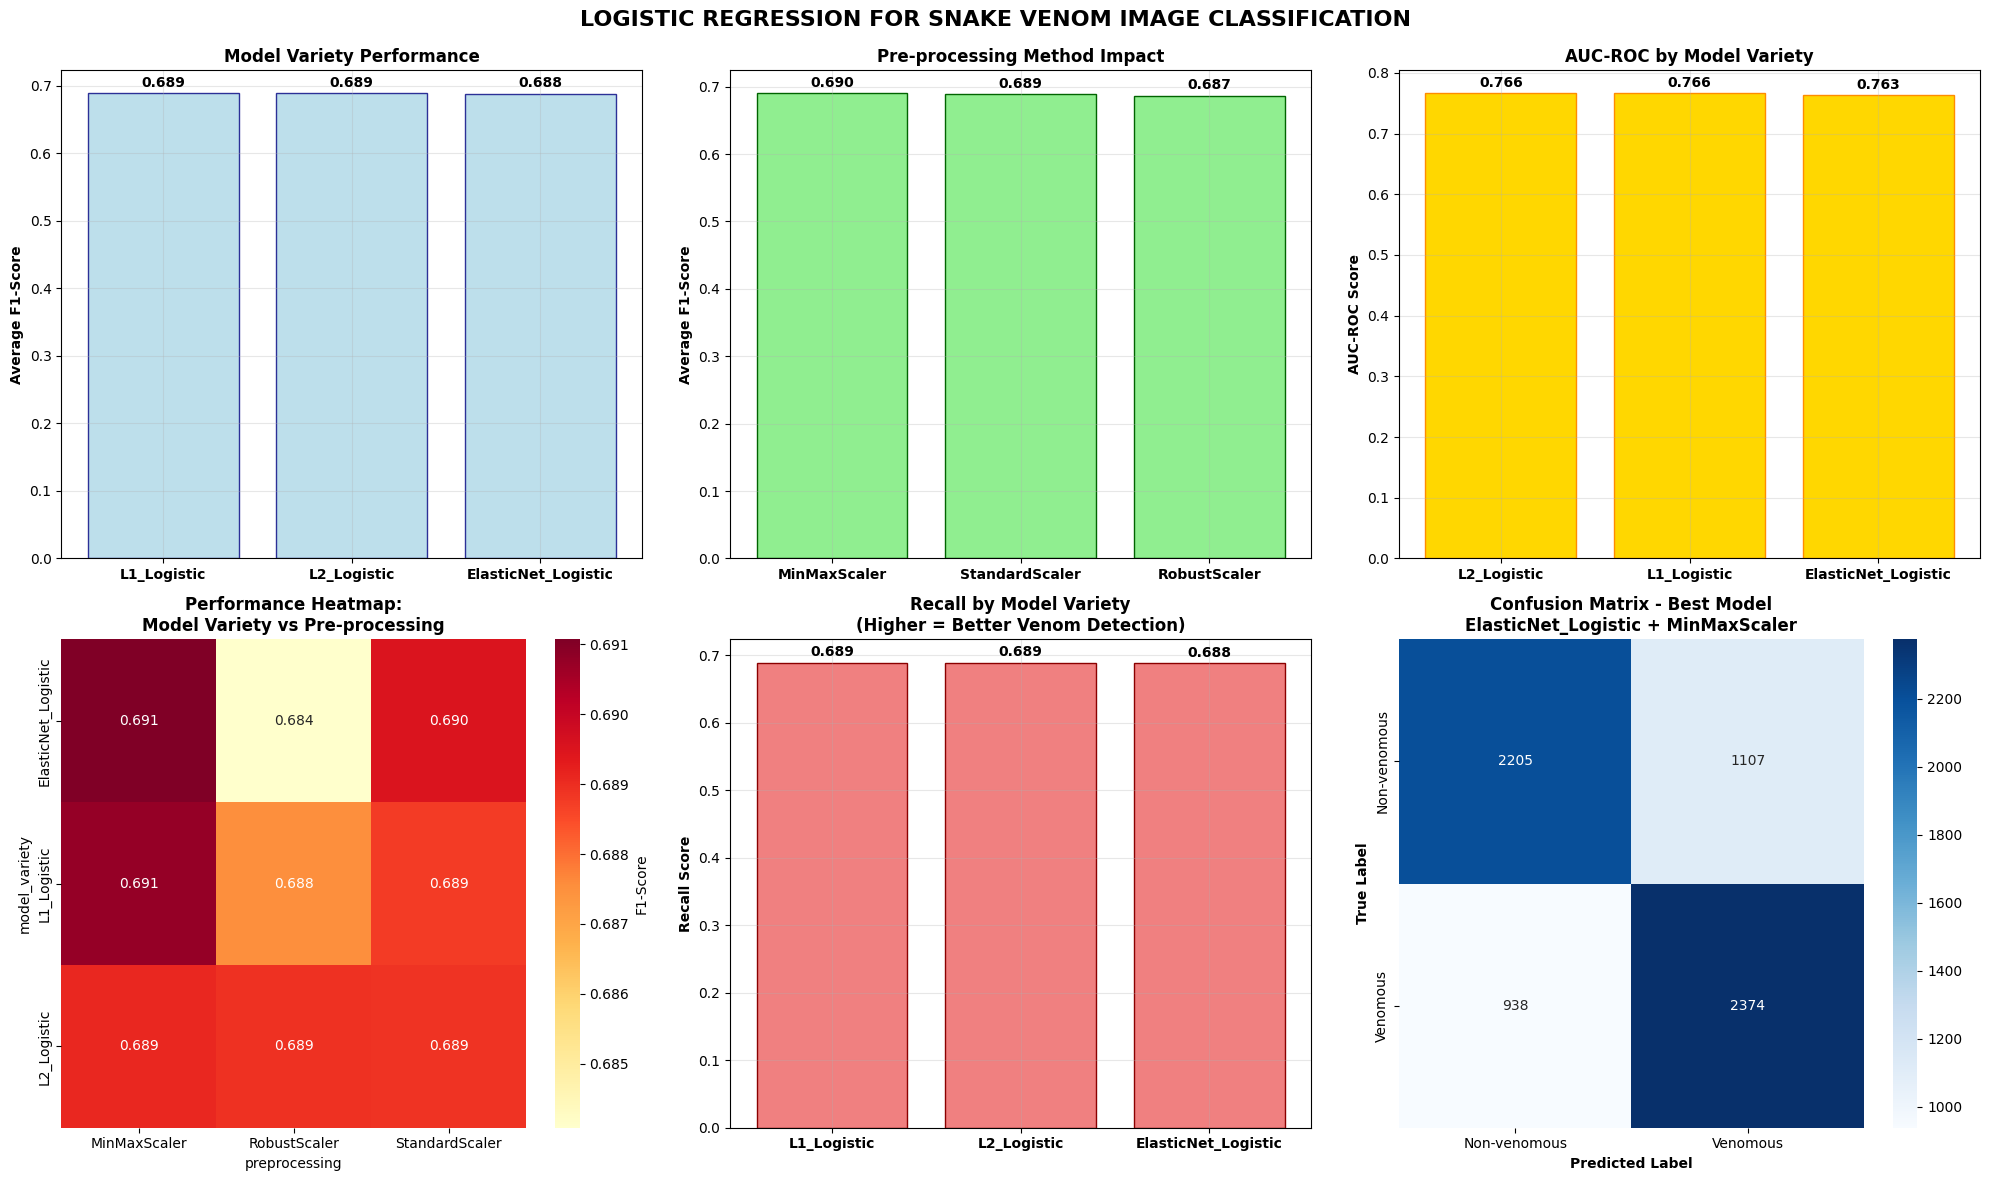

In [8]:
# 6. ADVANCED VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('LOGISTIC REGRESSION FOR SNAKE VENOM IMAGE CLASSIFICATION',
             fontsize=16, fontweight='bold')

# 1. Performance Comparison (F1-Score) by Model Variety
variety_f1 = results_df.groupby('model_variety')['f1'].mean().sort_values(ascending=False)
bars1 = axes[0,0].bar(range(len(variety_f1)), variety_f1.values, color='lightblue', edgecolor='navy', alpha=0.8)
axes[0,0].set_xticks(range(len(variety_f1)))
axes[0,0].set_xticklabels(variety_f1.index, rotation=0, fontweight='bold')
axes[0,0].set_ylabel('Average F1-Score', fontweight='bold')
axes[0,0].set_title('Model Variety Performance', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)

for i, v in enumerate(variety_f1.values):
    axes[0,0].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 2. Pre-processing Impact on F1-Score
preproc_f1 = results_df.groupby('preprocessing')['f1'].mean().sort_values(ascending=False)
bars2 = axes[0,1].bar(range(len(preproc_f1)), preproc_f1.values, color='lightgreen', edgecolor='darkgreen')
axes[0,1].set_xticks(range(len(preproc_f1)))
axes[0,1].set_xticklabels(preproc_f1.index, rotation=0, fontweight='bold')
axes[0,1].set_ylabel('Average F1-Score', fontweight='bold')
axes[0,1].set_title('Pre-processing Method Impact', fontweight='bold')
axes[0,1].grid(True, alpha=0.3)

for i, v in enumerate(preproc_f1.values):
    axes[0,1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 3. AUC-ROC Comparison
auc_data = results_df.groupby('model_variety')['auc'].mean().sort_values(ascending=False)
bars3 = axes[0,2].bar(range(len(auc_data)), auc_data.values, color='gold', edgecolor='darkorange')
axes[0,2].set_xticks(range(len(auc_data)))
axes[0,2].set_xticklabels(auc_data.index, rotation=0, fontweight='bold')
axes[0,2].set_ylabel('AUC-ROC Score', fontweight='bold')
axes[0,2].set_title('AUC-ROC by Model Variety', fontweight='bold')
axes[0,2].grid(True, alpha=0.3)

for i, v in enumerate(auc_data.values):
    axes[0,2].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Performance Heatmap (Model Variety vs Pre-processing)
pivot_data = results_df.pivot(index='model_variety', columns='preprocessing', values='f1')
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=axes[1,0],
            cbar_kws={'label': 'F1-Score'})
axes[1,0].set_title('Performance Heatmap:\nModel Variety vs Pre-processing', fontweight='bold')

# 5. Recall Comparison (Important for Snake Venom Classification)
recall_data = results_df.groupby('model_variety')['recall'].mean().sort_values(ascending=False)
bars5 = axes[1,1].bar(range(len(recall_data)), recall_data.values, color='lightcoral', edgecolor='darkred')
axes[1,1].set_xticks(range(len(recall_data)))
axes[1,1].set_xticklabels(recall_data.index, rotation=0, fontweight='bold')
axes[1,1].set_ylabel('Recall Score', fontweight='bold')
axes[1,1].set_title('Recall by Model Variety\n(Higher = Better Venom Detection)', fontweight='bold')
axes[1,1].grid(True, alpha=0.3)

for i, v in enumerate(recall_data.values):
    axes[1,1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')

# 6. Confusion Matrix for Best Model
best_model_info = best_overall
best_model = best_model_info['best_estimator']
y_pred_best = best_model_info['y_pred']
y_test_best = best_model_info['y_test']

cm = confusion_matrix(y_test_best, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1,2],
            xticklabels=['Non-venomous', 'Venomous'],
            yticklabels=['Non-venomous', 'Venomous'])
axes[1,2].set_title(f'Confusion Matrix - Best Model\n{best_model_info["model_variety"]} + {best_model_info["preprocessing"]}', fontweight='bold')
axes[1,2].set_xlabel('Predicted Label', fontweight='bold')
axes[1,2].set_ylabel('True Label', fontweight='bold')

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()


In [9]:
# 7. DETAILED CLASSIFICATION REPORT FOR BEST MODEL

print(f"Model: {best_model_info['model_variety']}")
print(f"Pre-processing: {best_model_info['preprocessing']}")
print(f"Best Parameters: {best_model_info['best_params']}")
print("="*70)
print(classification_report(y_test_best, y_pred_best,
                          target_names=['Non-venomous', 'Venomous']))


Model: ElasticNet_Logistic
Pre-processing: MinMaxScaler
Best Parameters: {'C': 10, 'l1_ratio': 0.8}
              precision    recall  f1-score   support

Non-venomous       0.70      0.67      0.68      3312
    Venomous       0.68      0.72      0.70      3312

    accuracy                           0.69      6624
   macro avg       0.69      0.69      0.69      6624
weighted avg       0.69      0.69      0.69      6624



In [10]:
# 8. SUMMARY AND CONCLUSIONS

print(f" MODEL VARIETIES EVALUATED: {len(lr_varieties)}")
print(f" PRE-PROCESSING METHODS: {len(preprocessing_methods)}")
print(f" TOTAL CONFIGURATIONS TESTED: {len(results_df)}")

print(f"\n BEST PERFORMING COMBINATION:")
print(f"   • Model: {best_model_info['model_variety']}")
print(f"   • Pre-processing: {best_model_info['preprocessing']}")
print(f"   • F1-Score: {best_model_info['f1']:.4f}")
print(f"   • Accuracy: {best_model_info['accuracy']:.4f}")

print(f"\n PERFORMANCE RANGE ACROSS ALL CONFIGURATIONS:")
print(f"   • F1-Score: {results_df['f1'].min():.4f} - {results_df['f1'].max():.4f}")
print(f"   • Accuracy: {results_df['accuracy'].min():.4f} - {results_df['accuracy'].max():.4f}")

print(f"\n KEY INSIGHTS:")
# Best model variety
best_variety = results_df.groupby('model_variety')['f1'].mean().idxmax()
print(f"   • Most robust model variety: {best_variety}")

# Best pre-processing
best_preproc = results_df.groupby('preprocessing')['f1'].mean().idxmax()
print(f"   • Most effective pre-processing: {best_preproc}")

# Clinical safety analysis
sensitivity = best_model_info['recall']  # Recall for venomous class
print(f"   • Sensitivity (Venom Detection): {sensitivity:.3f}")

print(f"\n DEPLOYMENT RECOMMENDATION:")
print(f"   • Use '{best_model_info['model_variety']}' with '{best_model_info['preprocessing']}' pre-processing")
print(f"   • Expected performance: {best_model_info['f1']:.1%} F1-Score")
print(f"   • Venom detection sensitivity: {sensitivity:.1%}")

# Save best model
joblib.dump(best_model, 'best_logistic_regression.pkl')
print(" Best model saved as 'best_logistic_regression.pkl'")

 MODEL VARIETIES EVALUATED: 3
 PRE-PROCESSING METHODS: 3
 TOTAL CONFIGURATIONS TESTED: 9

 BEST PERFORMING COMBINATION:
   • Model: ElasticNet_Logistic
   • Pre-processing: MinMaxScaler
   • F1-Score: 0.6911
   • Accuracy: 0.6913

 PERFORMANCE RANGE ACROSS ALL CONFIGURATIONS:
   • F1-Score: 0.6841 - 0.6911
   • Accuracy: 0.6843 - 0.6913

 KEY INSIGHTS:
   • Most robust model variety: L1_Logistic
   • Most effective pre-processing: MinMaxScaler
   • Sensitivity (Venom Detection): 0.691

 DEPLOYMENT RECOMMENDATION:
   • Use 'ElasticNet_Logistic' with 'MinMaxScaler' pre-processing
   • Expected performance: 69.1% F1-Score
   • Venom detection sensitivity: 69.1%
 Best model saved as 'best_logistic_regression.pkl'
